# CRT III - Assignment 1 - Parameter Estimation

## Introduction

This example focuses on the details involved in parameter estimation. Parameter estimation is a regurlarly occuring task in chemical reaction engineering, when experimental data is available but the details of the reaction kinetics are not yet known and some means of simulation is required to obtain this kinetic information. How this can be done for a rather simple isothermal and isochoric batch reactor, using `lmfit` module on some arbitrary "experimental" data, is illustrated in this example and part of the assignment.

## Reactor equations
A batch reactor with a liquid reaction phase of constant volume and temperature is considered. The governing equations for the time dependent concentration profiles are fairly simple:
\begin{equation}
    \frac{\partial{c_i}}{\partial{t}}=\sum_i{\nu_{i,j}\cdot r_j}
\end{equation}
The reaction rates are simply assumed to be just elementary reactions. Hence, the rate equations can be written as
\begin{equation}
    r_j = k_j \cdot c_i^{p_i} \cdot c_k^{p_k}
\end{equation}
in which each reaction rate equation requires the provision of a kinetic parameter and potentially also reaction orders.<br>
For any solution, the set of ode's requires initial conditions, here the concentration at the start.
\begin{equation}
    c(t=0)_i=c_{i,0}
\end{equation}

## General programming approach
A numerical integration to obtain a solution in a given timescale can easily be obtained with the method
`scipy.integrate.solve_ivp`. However, this only works for a specified set of known parameters, within a given time range. And every simulation only calculates the values for a single experiment. Therefore, a wrapping function needs to do the calculation for all experiments combined. As a last step and within an outer function the residuals on these simulated data needs to be computed to allow for an automated minimisation. This is done with the `lmfit.Minimizer` method, that attempts to find parameters that minimise the total squared sum of the residual.
Further, management of the data for estimation requires reading files and working with data lists to correctly address and access data.
Links:
[ode solution: solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)
[Fitting with lmfit](https://lmfit.github.io/lmfit-py/fitting.html#minimizer-emcee-calculating-the-posterior-probability-distribution-of-parameters)

## Step 1: Retrieving data
The data to be used for the estimation is stored in individual csv-files for each run of the reactor, containing time-stamps (in min) and concentration levels (in mol/m³) for each of the four species (Ab, B, C and D). The code uses the module `os` to obtain the number of files in the directory provided. This allows a for-loop to read the csv-file and store the data of each experiment in an array and append these arrays to a list, which will subsequently be used for the estimation.
NOTE: Please copy and place the data on your machine in an empty directory AND change the string accordingly when you are working on the assignment.

In [1]:
import numpy as np
import pandas as pd
import os

# store the generic path to the assignment and the data
path = r"C:\Users\ASUS\Nextcloud\5_Lehre_2023_CRE-3\2_Assignments\Archiv_2026\Assignment_1\Data_intro" # this needs to be changed according to your data directory

# create list of files in directory
os_list = os.listdir(path)
# provide length of list, which equals the number of experiments (nex)
nex = len(os_list)

# create empty list for concentrations, times and initials to store experimental results
exp_concs = []
t_eval = []
c_inits = []
for i in np.arange(0, nex):
    # iterate over all csv-files and append them, after transposing, as array to the list
    aux = pd.read_csv(path + r'\Exp_res_' + str(i) + '.csv')
    t_eval.append(aux.values.transpose()[0, :])
    c_inits.append(aux.values.transpose()[1:, 0])
    exp_concs.append(aux.values.transpose()[1:, :])

# Create flattened array of results
nex = len(exp_concs)
exp_concs_flat = np.array([])
for i in np.arange(0, nex):
    exp_concs_flat = np.append(exp_concs_flat, exp_concs[i])

The data from the csv files is stored in three lists. One for the actual concentration values `exp_concs`, another one for the times at which the concnetrations where measured `t_eval` and a last list containing the initial concentrations, `c_inits`. Finally, the concentration list is also flattened into one vector-like array, for later use with the `minimize` method of `lmfit`.
NOTE: Lists with arrays as entries are used instead of an array with more dimensions, as the number of points between the experiments is not necessarily the same. Though, one could have used an array that is sufficiently large to store all data, it would have also included either some arbitrary data or some garbage collected data probably causing the fit to fail.

## Step 2: Plot the experimental data & investigate
Once the data is stored in `exp_conc` and `t_eval`it can be accessed for plotting. Please note that each element in the list is an array, hence to index a particular datum one first needs an integer within a pair of brackets to obtain the right element of the list and then one needs a second pair of brackets with appropriate indices to access the desired element of the array.<br>
For later interpretation also the cumulative concentration is plotted.

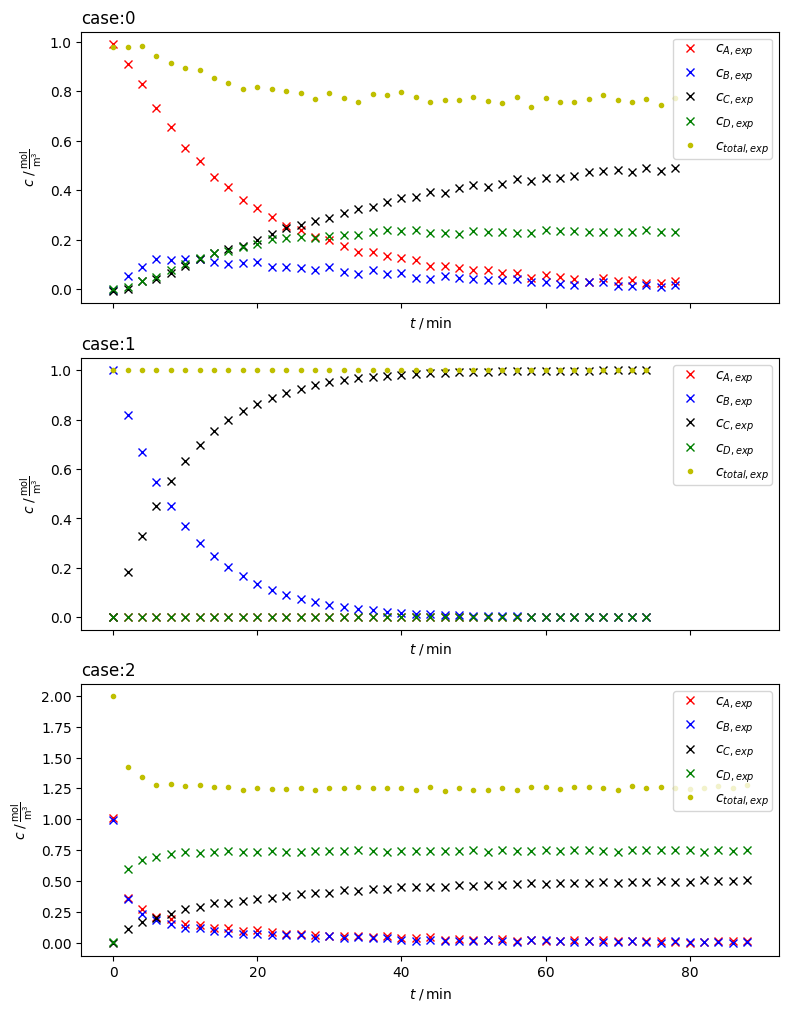

In [2]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=nex, figsize=(9,12), sharex=True)

for i in np.arange(0, nex):
    # PLOTTING
    cum_c = np.sum(exp_concs[i][:, :], axis=0)
    axs[i].plot(t_eval[i], exp_concs[i][0, :], 'rx', label='$c_{A,exp}$')  # plot c_A over t
    axs[i].plot(t_eval[i], exp_concs[i][1, :], 'bx', label='$c_{B,exp}$')  # plot c_B over t
    axs[i].plot(t_eval[i], exp_concs[i][2, :], 'kx', label='$c_{C,exp}$')  # plot c_C over t
    axs[i].plot(t_eval[i], exp_concs[i][3, :], 'gx', label='$c_{D,exp}$')  # plot c_D over t
    axs[i].plot(t_eval[i], cum_c, 'y.', label='$c_{total,exp}$')  # plot cumulative concentration over t
    axs[i].set(xlabel=r'$t\; / \, \mathrm{min}$', ylabel=r'$c\; / \, \mathrm{\frac{mol}{m^3}}$')  #
    axs[i].legend(loc="upper right", borderpad=0.2)
    axs[i].set_title("case:" + str(i), loc="left")

plt.show()

The "experimental" data, albeit being numerically generated, features some characteristics that are typical although often undesired. First, the values are noisy, meaning there is a quite a bit of random scattering, which will always occur, whilst collecting numerical information. Secondly, and this can be altered by design of the experiments, the time-steps and number of points per experiments are not constant. Although this is a mere discomfort it has to be accounted for and occurs in real life more often than not.<br>


## Step 3: Build a reaction hypothesis
### case 0
From _case 0_, where only A is initially present, one can clearly derive a consecutive reaction in form of
\begin{equation}
    x A \rightarrow  y B \rightarrow  z C
\end{equation}
and
\begin{equation}
    v B \rightarrow w D
\end{equation}
because A is only consumed, B exhibits an intermittent maximum and C and D are apparently only rising. However, the reaction does not conserve the total molar amount.

### case 1
From _case 1_ it becomes clear that B only reacts to C, since no change in the total concentration occurs and also A and D are also not observed.
\begin{equation}
    1 B \rightarrow  1 C
\end{equation}

### case 2
To include the volume reduction and substantial formation of D, as observed in _case 2_, three simple options are available.
\begin{equation}
    2 A \rightarrow  1 D
\end{equation}
\begin{equation}
    A + B \rightarrow  1 D
\end{equation}
\begin{equation}
    2 B \rightarrow  1 D
\end{equation}
The first is in contradiction to the results ase one would expect less and not more of D when B and A are initially present. The last one would be in violation of the results observed in _case 1_. Thus, only a conversion of A with B to D seems reasonable.


## Step 4: Create Solution functions
To test the hypothesis the mass balance of the reactor and the rate equations are set up accordingly.

In [3]:
def ode(t, c, k):
    """
    Calculate time derivatives of the ode for a batch STR
    Parameters
    ----------
    t: float
        time of the calculation
    c: array
        concentration values at time t, size [nc]
    k: array
        kinetic coefficients for all reactions, size [nr]

    Returns
    -------
    dcdt: array
        time derivatives of the concentration, size [nc]
    """
    dcdt = np.zeros_like(c)
    # calculating the rates
    r0 = k[0] * c[0]
    r1 = k[1] * c[1]
    r2 = k[2] * c[0] * c[1]

    # calculating the derivatives
    dcdt[0] = - r0 - r2
    dcdt[1] = + r0 - r1 - r2
    dcdt[2] = + r1
    dcdt[3] = + r2
    return dcdt

The second function to be defined is used to actually calculate the time dependent concentration values for given initial conditions and (assumed) kinetic constants. By doing so it simulates the run of an actual experiment, hence the name.

In [4]:
import scipy.integrate as integ

def sim_exp(t, c_init, k):
    """
    Simulate single experiment using solve_ivp.
    Parameters
    ----------
    t: array
       array with the time points of the simulation, size [nt]
    c_init: array
        initial concentrations, size [nc]
    k: array
        kinetic coefficients for all reactions, size [nr]

    Returns
    -------
    c_sol: array
        concentration values at times defined by t, size [nc, nt]
    """
    t_sp = np.array([t[0], t[-1]])
    sol = integ.solve_ivp(fun=ode, t_span=t_sp, y0=c_init, method='LSODA', t_eval=t, args=[k])
    c_sol = sol.y
    return c_sol

The third function wraps the computation of individual experiments into a top level function and returns a list of concentration values of the same size as `exp_concs`.

In [5]:
def sim_multiple_exps(times, k0, k1, k2, c_inits):
    """
    Simulate results for n experiments with nc components and 3 reactions. Each experiment has nt_i entries.

    Parameters
    ----------
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]
    k0: float
        Kinetic parameter of first reaction
    k1: float
        Kinetic parameter of second reaction
    k2: float
        Kinetic parameter of third reaction
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]


    Returns
    -------
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = sim_exp(t, c_0, k)
        sim_concs.append(conc)
    return sim_concs

The last function is set up to allow execution by lmfit, which means that a parameter object is handed as an argument, besides other parameters and the data to compare the simulation against.

In [6]:
def residual(params, times, c_inits, data):
    """
    Calculate the difference between simulation and experiment for each provided datum.
    Parameters
    ----------
    params: Parameters
        Parameter object containing all variables to be estimated
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    data: list
        List of arrays with concentration values from experiment, size[n][nc, nt_i].
    Returns
    -------
    concs_flat - data: array
        flattened array of differences between simulation and experimental data, size[n*nc*nt_i]
    """
    # number of experiments from length
    sim_conc = sim_multiple_exps(times, params["k0"], params["k1"], params["k2"], c_inits)

    nex = len(times)
    concs_flat = np.array([])
    for i in np.arange(0, nex):
        concs_flat = np.append(concs_flat, sim_conc[i])

    return concs_flat - data

## Step 5: Compute estimated parameters & Plot results
With all these definitions done, all that is left is to run the actual estimation by instantiating a Parameter object and a Minimizer object to start the minimisation of the residual.

In [7]:
from lmfit import Model, Minimizer, Parameters, report_fit

params = Parameters()
params.add('k0', value=0.5, min=0, max=10, vary=True)
params.add('k1', value=0.5, min=0, max=10, vary=True)
params.add('k2', value=0.5, min=0, max=10, vary=True)

minner = Minimizer(residual, params, fcn_args=(t_eval, c_inits, exp_concs_flat))
result = minner.minimize()
report_fit(result)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 492
    # variables        = 3
    chi-square         = 1.45828476
    reduced chi-square = 0.00298218
    Akaike info crit   = -2858.03915
    Bayesian info crit = -2845.44372
[[Variables]]
    k0:  0.03943698 +/- 0.00127678 (3.24%) (init = 0.5)
    k1:  0.10661490 +/- 0.00334362 (3.14%) (init = 0.5)
    k2:  0.38158114 +/- 0.01248935 (3.27%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k1, k2) = +0.6923
    C(k0, k2) = +0.2359


With the now estimated parameters one can simply create the data with the `model` class of `lmfit`. And plot the fitted results.

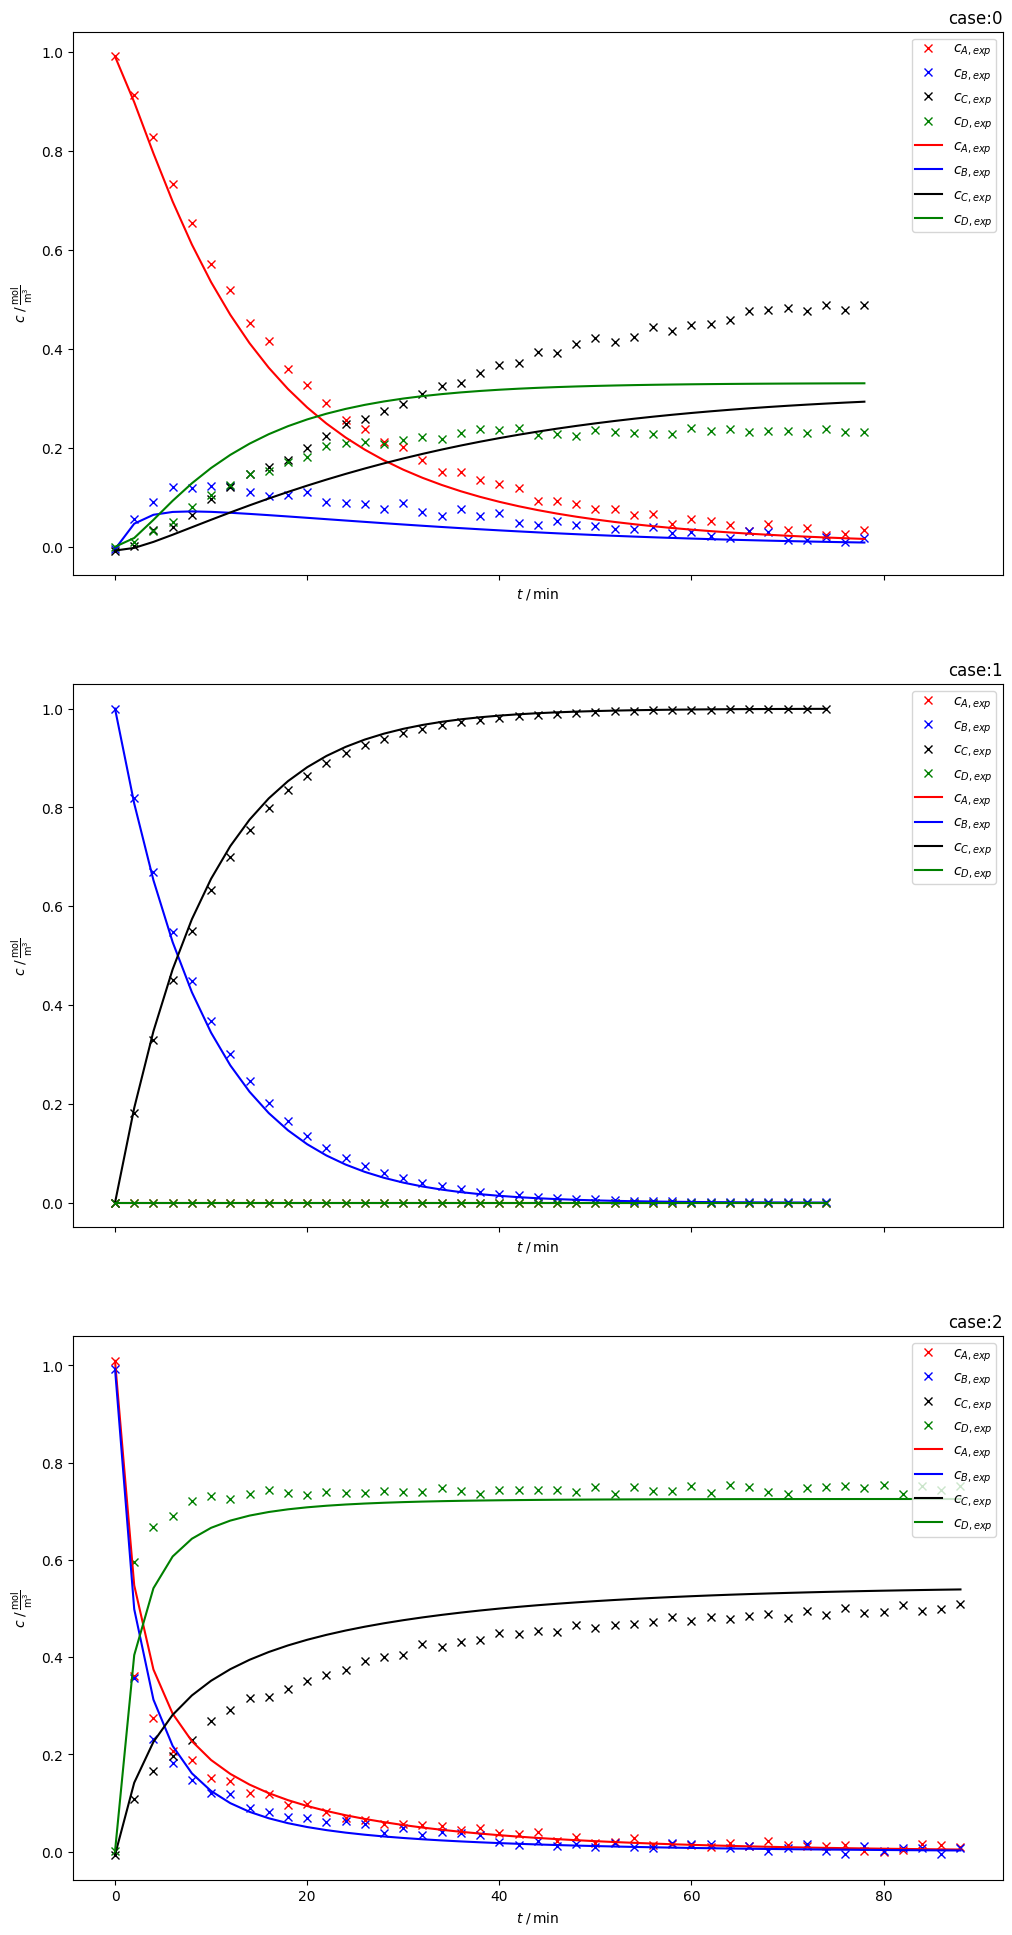

In [8]:
model = Model(sim_multiple_exps, independent_vars=['times', 'c_inits'])
best_fit = sim_multiple_exps(times=t_eval, k0=result.params['k0'], k1=result.params['k1'], k2=result.params['k2'], c_inits=c_inits)

# PLOTTING
fig, axs = plt.subplots(nrows=nex, figsize=(12, 24), sharex=True)

for i in np.arange(0, nex):
    axs[i].plot(t_eval[i], exp_concs[i][0, :], 'rx', label='$c_{A,exp}$')  # plot c0 over t
    axs[i].plot(t_eval[i], exp_concs[i][1, :], 'bx', label='$c_{B,exp}$')  # plot c1 over t
    axs[i].plot(t_eval[i], exp_concs[i][2, :], 'kx', label='$c_{C,exp}$')  # plot c2 over t
    axs[i].plot(t_eval[i], exp_concs[i][3, :], 'gx', label='$c_{D,exp}$')  # plot c3 over t
    axs[i].plot(t_eval[i], best_fit[i][0, :], 'r-', label='$c_{A,exp}$')  # plot c0 over t
    axs[i].plot(t_eval[i], best_fit[i][1, :], 'b-', label='$c_{B,exp}$')  # plot c1 over t
    axs[i].plot(t_eval[i], best_fit[i][2, :], 'k-', label='$c_{C,exp}$')  # plot c2 over t
    axs[i].plot(t_eval[i], best_fit[i][3, :], 'g-', label='$c_{D,exp}$')  # plot c3 over t
    axs[i].set(xlabel=r'$t\; / \, \mathrm{min}$', ylabel=r'$c\; / \, \mathrm{\frac{mol}{m^3}}$')  #
    axs[i].legend(loc="upper right", borderpad=0.2)
    axs[i].set_title("case:" + str(i), loc="right")

plt.show()

## Step 6: Check for plausibility (and improve)
A vital step after a numerically succesful parameter estimation is checking the results for plausibility and validity. Therefore, in this case, just plotting the obtained simulation results along with experimental values suffices. Especially for `case 0` the concentration of the final products is still off. One can modify the network or attempt to improve the order in the rate equations. After some tests a change of the order toward species B for the third reaction, the estimation yields much  improved results.

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 492
    # variables        = 3
    chi-square         = 0.01528581
    reduced chi-square = 3.1259e-05
    Akaike info crit   = -5100.62010
    Bayesian info crit = -5088.02467
[[Variables]]
    k0:  0.04067628 +/- 1.2512e-04 (0.31%) (init = 0.5)
    k1:  0.10095537 +/- 3.1060e-04 (0.31%) (init = 0.5)
    k2:  1.47697014 +/- 0.00723219 (0.49%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k1, k2) = +0.7428


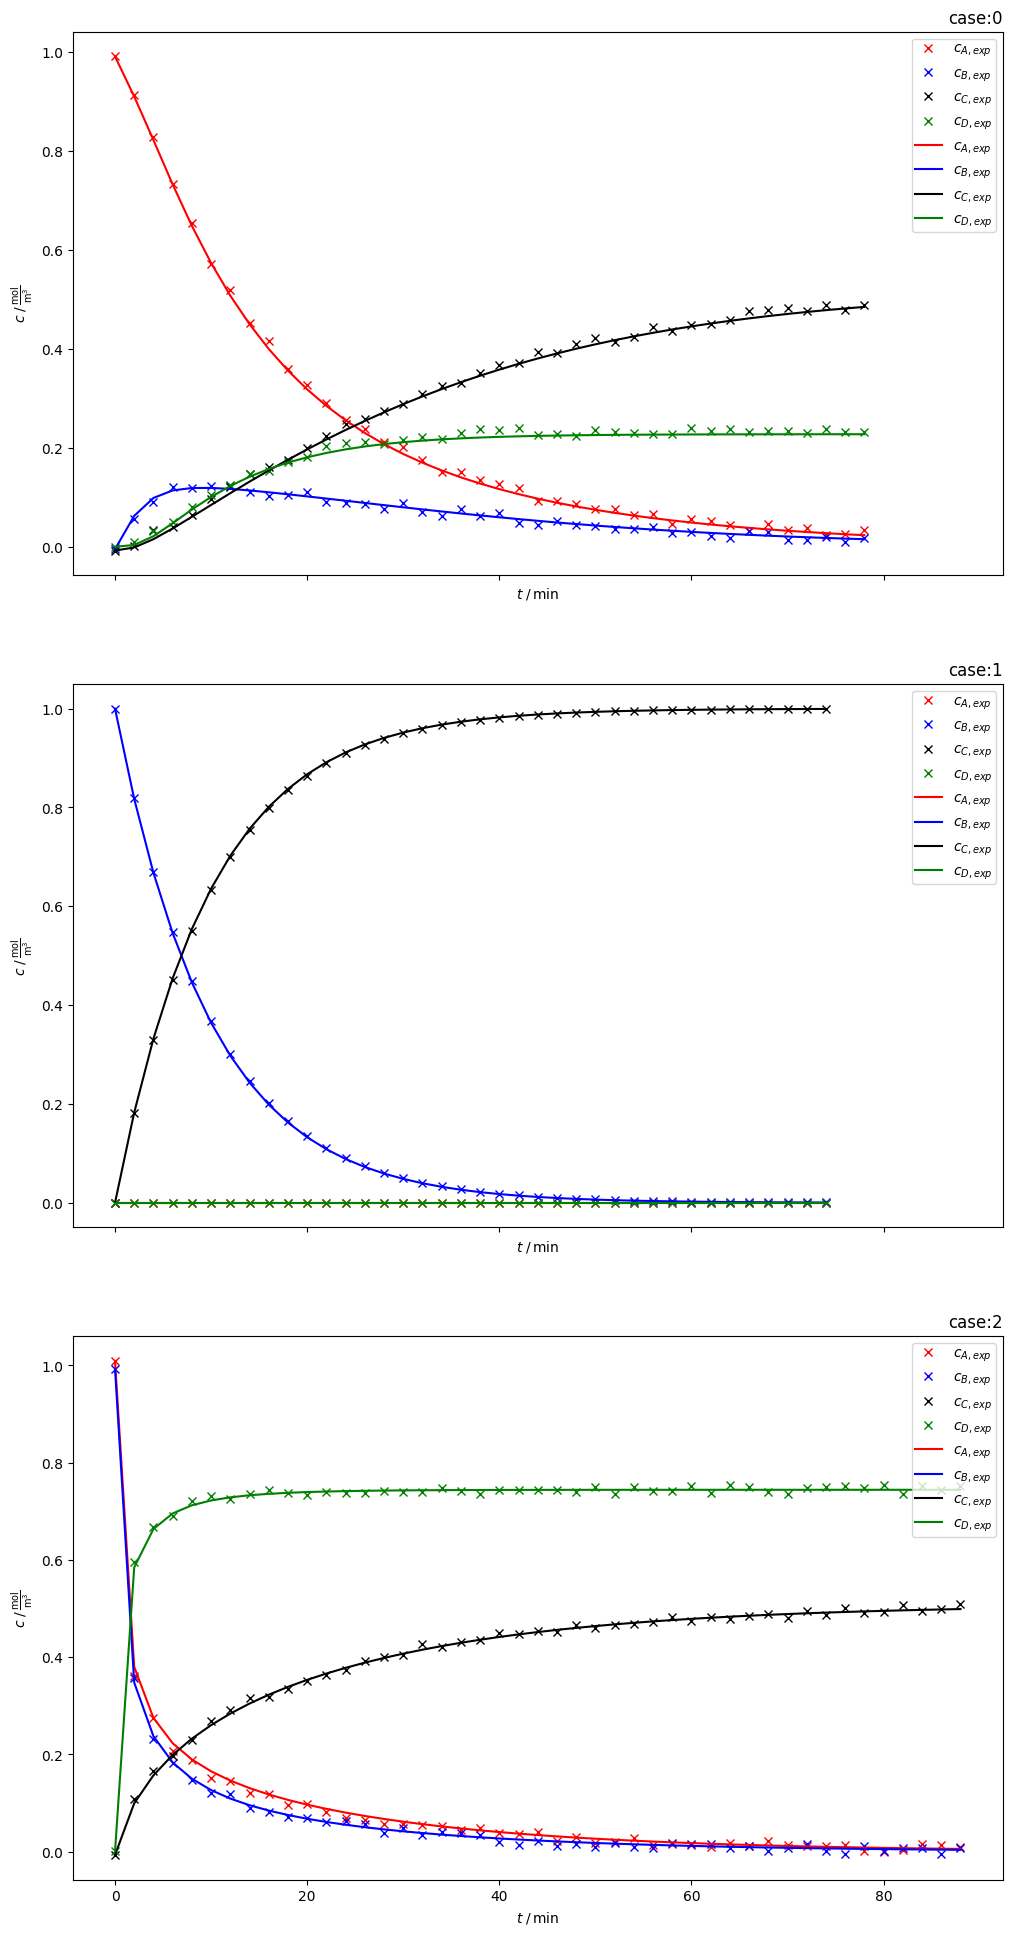

In [9]:
def ode(t, c, k):
    dcdt = np.zeros_like(c)
    # calculating the rates
    # r0 = k[0] * np.sign(c[0])*abs(c[0]) ** 0.5
    r0 = k[0] * c[0] ** 1.
    r1 = k[1] * c[1] ** 1.
    r2 = k[2] * c[0] ** 1. * c[1] ** 2.

    # calculating the derivatives
    dcdt[0] = - r0 - r2
    dcdt[1] = + r0 - r1 - r2
    dcdt[2] = + r1
    dcdt[3] = + r2
    return dcdt

minner = Minimizer(residual, params, fcn_args=(t_eval, c_inits, exp_concs_flat))
result = minner.minimize()
report_fit(result)

model = Model(sim_multiple_exps, independent_vars=['times', 'c_inits'])
best_fit = sim_multiple_exps(times=t_eval, k0=result.params['k0'], k1=result.params['k1'], k2=result.params['k2'], c_inits=c_inits)

# PLOTTING
fig, axs = plt.subplots(nrows=nex, figsize=(12, 24), sharex=True)

for i in np.arange(0, nex):
    axs[i].plot(t_eval[i], exp_concs[i][0, :], 'rx', label='$c_{A,exp}$')  # plot c0 over t
    axs[i].plot(t_eval[i], exp_concs[i][1, :], 'bx', label='$c_{B,exp}$')  # plot c1 over t
    axs[i].plot(t_eval[i], exp_concs[i][2, :], 'kx', label='$c_{C,exp}$')  # plot c2 over t
    axs[i].plot(t_eval[i], exp_concs[i][3, :], 'gx', label='$c_{D,exp}$')  # plot c3 over t
    axs[i].plot(t_eval[i], best_fit[i][0, :], 'r-', label='$c_{A,exp}$')  # plot c0 over t
    axs[i].plot(t_eval[i], best_fit[i][1, :], 'b-', label='$c_{B,exp}$')  # plot c1 over t
    axs[i].plot(t_eval[i], best_fit[i][2, :], 'k-', label='$c_{C,exp}$')  # plot c2 over t
    axs[i].plot(t_eval[i], best_fit[i][3, :], 'g-', label='$c_{D,exp}$')  # plot c3 over t
    axs[i].set(xlabel=r'$t\; / \, \mathrm{min}$', ylabel=r'$c\; / \, \mathrm{\frac{mol}{m^3}}$')  #
    axs[i].legend(loc="upper right", borderpad=0.2)
    axs[i].set_title("case:" + str(i), loc="right")

plt.show()

# Assignment
## Tasks
- load the provided csv-files into the active notebook and plot the data as concentration over time for all experiments
- deduce a plausible reaction network and set up a kinetic model to test this hypothesis
- run a parameter estimation and estimate the kinetic constant for each reaction
- check if the obtained parameters are viable and compare the simulated results against the experimental ones to discuss whether the hypothesized reaction network is appropriate or not
- when the proposed reaction network is highly inadequate attempt to improve the reaction network or kinetics and redo the estimation and discuss the results again

## Learning aims
The students that have completed the assignment tasks are able to:
- formulate a sound hypothesis for the reaction network and kinetics to be tested via parameter estimation
- understand the method by which the parameter estimation works, especially when more than one experiment is used for the calculation
- can check the obtained parameter estimates and simulation results based thereof for plausibility
- can validate or falsify the proposed hypothesis and improve the hypothesis if needed

## Hints
- if the reaction network does not yield satisfying results one could also attempt to introduce kinetic orders above or below one, by assigning and exponent to the rate and also including it into the fuction code; though it is not recommended
- proper understanding of data organisation is of paramount interest when dealing with larger sets of data, which is typical for parameter estimation
    - attempt to modify data for the example and re-run the example sheet
    - you can also create data on your own and attempt including it
    - Reading the csv-files requires to have set a correct directory which will likely be different for each user and therefor needs to be changed according to the storage location
- Using nested functions allows for a staged testing of these functions
    - beginning from the inner functions allows to avoid the use of dummy functions for the outer ones
    - check if the returned variables are of correct size and data type for a variety of sensible and also unreasonable inputs
    - continue to the next level of hierarchy only when the previous function works reliably
- parameter estimation can be heavily influenced by the starting guess for these parameters
    - check that only viable guesses are used (within bounds, see next bullet point)
    - use proper bounds:
        - e.g. mostly only positive constants
        - exponents not in excess of 3 (and even that is already fairly high) or below -2 (if negative at all)
        - check for maximum magnitude for constants (e.g. $10^5$) depending on units/ time scale, test manually beforehand